In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## Data Preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
!wget $data

--2026-05-26 13:33:33--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.03s   

2026-05-26 13:33:33 (27.8 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [88]:
df = pd.read_csv('/content/car_fuel_efficiency.csv')

In [89]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [90]:
df.dtypes == 'object'

,0
engine_displacement,False
num_cylinders,False
horsepower,False
vehicle_weight,False
acceleration,False
model_year,False
origin,True
fuel_type,True
drivetrain,True
num_doors,False


In [91]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [92]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [93]:
print("{} : \n {} \n".format('total houses (rows)', len(df)))

total houses (rows) : 
 9704 



In [94]:
df.head(10)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369
5,190,3.0,NaN,2484.883986,14.7,2008,europe,gasoline,all-wheel_drive,-1.0,17.271818
6,240,7.0,127.0,3006.542287,22.2,2012,usa,gasoline,front-wheel_drive,1.0,13.210412
7,150,4.0,239.0,3638.657780,17.3,2020,usa,diesel,all-wheel_drive,1.0,12.848884
8,250,1.0,174.0,2714.219310,10.3,2016,asia,diesel,front-wheel_drive,-1.0,16.823554
9,150,4.0,123.0,3509.036569,10.2,2005,usa,gasoline,front-wheel_drive,-1.0,12.298355


In [95]:
len(df)

9704

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [97]:
selected_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_type',
]

filtered_df = df[selected_columns]

print(filtered_df.head())

   engine_displacement  horsepower  vehicle_weight  model_year fuel_type
0                  170       159.0     3413.433759        2003  gasoline
1                  130        97.0     3149.664934        2007  gasoline
2                  170        78.0     3079.038997        2018  gasoline
3                  220         NaN     2542.392402        2009    diesel
4                  210       140.0     3460.870990        2009  gasoline


## Exploratory data analysis (EDA)

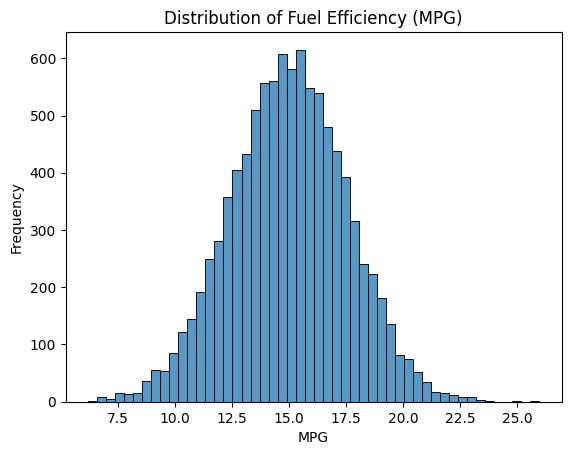

In [98]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

Q1: There's one column with missing values. What is it?

In [99]:
# Count missing values in each selected column
missing_counts = df[selected_columns].isnull().sum()
print(missing_counts)

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_type                0
dtype: int64


In [100]:
# Mean
mean_hp = df['horsepower'].mean()
print("Mean horsepower:", mean_hp)

Mean horsepower: 149.65729212983547


In [101]:
# Median
median_value = df['horsepower'].median()
print("Median horsepower:", median_value)

Median horsepower: 149.0


In [102]:
# Mode
mode_value = df['horsepower'].mode()
print("Median horsepower:", mode_value)

Median horsepower: 0    152.0
Name: horsepower, dtype: float64


Q2: What's the median (50% percentile) for variable `'horsepower'`?

In [103]:
median_hp = df['horsepower'].median()
print("Median horsepower:", median_hp)

Median horsepower: 149.0


In [104]:
df['horsepower'].isnull().sum()

np.int64(708)

In [105]:
print("Mean horsepower used for filling:", df['horsepower'].mean())

Mean horsepower used for filling: 149.65729212983547


In [106]:
print("filling horsepower with 0:", df['horsepower'].fillna(0))

filling horsepower with 0: 0       159.0
1        97.0
2        78.0
3         0.0
4       140.0
        ...  
9699    164.0
9700    154.0
9701    138.0
9702    177.0
9703    140.0
Name: horsepower, Length: 9704, dtype: float64


Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Q3: Which option gives better RMSE?

## Setting up the validation framework

In [107]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [108]:
n

9704

In [109]:
n, n_test, n_val, n_train

(9704, 1940, 1940, 5824)

In [110]:
df.loc[[10, 0, 3, 5], selected_columns]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_type
10,230,100.0,3111.810181,2014,diesel
0,170,159.0,3413.433759,2003,gasoline
3,220,NaN,2542.392402,2009,diesel
5,190,NaN,2484.883986,2008,gasoline


In [111]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [112]:
idx = np.arange(n)

In [113]:
np.random.seed(42)
np.random.shuffle(idx)

In [114]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [115]:
df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,usa,gasoline,all-wheel_drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,asia,diesel,front-wheel_drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,asia,diesel,front-wheel_drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,usa,gasoline,all-wheel_drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,usa,gasoline,all-wheel_drive,NaN,19.402209


In [116]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [117]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [118]:
np.log1p(df_train.horsepower)

,horsepower
0,4.976734
1,4.955827
2,5.049856
3,5.332719
4,4.718499
...,...
5819,4.941642
5820,4.890349
5821,5.030438
5822,5.043425


In [119]:
np.log1p(df_train.horsepower.values)

array([4.97673374, 4.95582706, 5.04985601, ..., 5.03043792, 5.04342512,
       5.03043792])

In [120]:
y_train = np.log1p(df_train.horsepower.values)
y_val = np.log1p(df_val.horsepower.values)
y_test = np.log1p(df_test.horsepower.values)

In [121]:
y_val

array([4.72738782, 4.93447393, 5.20400669, ..., 5.31320598, 5.13579844,
       4.77068462])

In [122]:
del df_train['horsepower']
del df_val['horsepower']
del df_test['horsepower']

In [123]:
len(y_train)

5824

In [124]:
df_train.iloc[10]

,10
engine_displacement,240
num_cylinders,2.0
vehicle_weight,2916.987921
acceleration,16.3
model_year,2001
origin,asia
fuel_type,gasoline
drivetrain,front-wheel_drive
num_doors,1.0
fuel_efficiency_mpg,15.066416


In [125]:
xi = [240, 16.3, 15.066416]
xi

[240, 16.3, 15.066416]

In [126]:
xi = [240, 16.3, 15.066416]
w0 = 5.17 # bias term
w = [0.01, 0.04, 0.002]

In [127]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [128]:
linear_regression(xi)

8.252132832

In [129]:
np.exp(8.252132832)

np.float64(3835.7982163505876)

In [130]:
np.expm1(8.252132832)

np.float64(3834.7982163505876)

In [131]:
np.log1p(3834.7982163505876)

np.float64(8.252132832)

In [132]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [133]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [134]:
w_new = [w0] + w

In [135]:
w_new

[5.17, 0.01, 0.04, 0.002]

In [136]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [137]:
linear_regression(xi)

8.252132832

In [138]:
w0 = 5.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w
w_new

[5.17, 0.01, 0.04, 0.002]

In [139]:
x1  = [1, 148, 12.2, 12.066341]
x2  = [1, 132, 14.3, 13.056432]
x10 = [1, 240, 16.3, 15.066416]

X = [x1, x2, x10]
X = np.array(X)
X

array([[  1.      , 148.      ,  12.2     ,  12.066341],
       [  1.      , 132.      ,  14.3     ,  13.056432],
       [  1.      , 240.      ,  16.3     ,  15.066416]])

In [140]:
X.dot(w_new)

array([7.16213268, 7.08811286, 8.25213283])

In [141]:
def linear_regression(X):
    return X.dot(w_new)

In [142]:
linear_regression(X)

array([7.16213268, 7.08811286, 8.25213283])

In [143]:
X = [
    [148, 12.2, 12.066341],
    [148, 12.2, 12.066341],
    [148, 12.2, 12.493883],
    [120, 13.2, 13.066341],
    [148, 12.7, 15.084362],
    [324, 13.9, 13.066341],
    [111, 12.2, 12.045341],
    [102, 18.2, 16.066341],
    [321, 12.2, 11.066341],
]

X = np.array(X)
X

array([[148.      ,  12.2     ,  12.066341],
       [148.      ,  12.2     ,  12.066341],
       [148.      ,  12.2     ,  12.493883],
       [120.      ,  13.2     ,  13.066341],
       [148.      ,  12.7     ,  15.084362],
       [324.      ,  13.9     ,  13.066341],
       [111.      ,  12.2     ,  12.045341],
       [102.      ,  18.2     ,  16.066341],
       [321.      ,  12.2     ,  11.066341]])

In [144]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [145]:
X = np.column_stack([ones, X])

In [146]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [147]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [148]:
w0 = w_full[0]
w = w_full[1:]

In [149]:
w0, w

(np.float64(1514.9618640805727),
 array([   -9.61390261,  2912.62517496, -1692.79151316]))

In [150]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [151]:
def _raise_linalgerror_singular(err, flag):
    raise _raise_linalgerror_singular("Singular matrix")

In [152]:
train_linear_regression(X, y)

(np.float64(757.4809320764296),
 array([  757.48093208,    -9.61390261,  2912.62517496, -1692.79151316]))

In [153]:
df_train.columns

Index(['engine_displacement', 'num_cylinders', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [154]:
base = ['engine_displacement',
    'acceleration',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [155]:
df_train[base].isnull().sum()

,0
engine_displacement,0
acceleration,551
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [156]:
df_train[base] = df_train[base].fillna(df_train[base].mean())
df_train[base].isnull().sum()

,0
engine_displacement,0
acceleration,0
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [157]:
df_train[base].fillna(0).isnull().sum()

,0
engine_displacement,0
acceleration,0
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [158]:
w0

np.float64(nan)

In [159]:
w

array([nan, nan, nan, nan, nan])

In [78]:
w0, w = train_linear_regression(X_train, y_train)

In [79]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

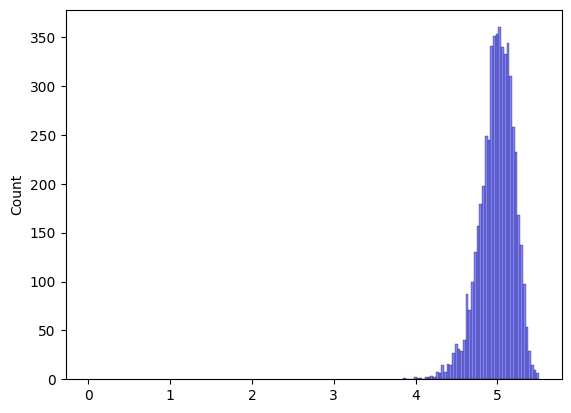

In [80]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

Options:
* With 0

In [81]:
X_train_0 = df_train[base].fillna(0).values
X_val_0 = df_val[base].fillna(0).values

In [82]:
mean_values = df_train[base].mean()
X_train_mean = df_train[base].fillna(mean_values).values
X_val_mean = df_val[base].fillna(mean_values).values

In [83]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

Options:
* With mean

In [84]:
rmse(y_train, y_pred)

np.float64(nan)

In [160]:
score = np.float64(0.1686528610978111)
rounded_score = round(score, 2)
print(rounded_score)

0.17


In [161]:
rmse_std = round(np.std(score), 2)
print("RMSE Standard Deviation:", rmse_std)

RMSE Standard Deviation: 0.0


In [162]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [163]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(nan)